### Laxmi Bhargav Mende - 25B0940

## LS 26 - Agentic AI [Analytics Club]

### Week4: Capstone Project

#### Global Variables and Functions

In [210]:
import os
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer, util
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv('~/.env')

embeddingmodel = SentenceTransformer('BAAI/bge-small-en-v1.5')

llm = ChatGoogleGenerativeAI(
    model = 'gemini-3.1-flash-lite'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [211]:
import sys
import select

def input_with_timeout(prompt: str, default: str, timeout: int = 10) -> str:
    """
    Waits for user terminal input with a strict timeout window.
    Defaults to the fallback string if the user does not respond.
    """
    print(prompt, end="", flush=True)
    # select.select monitors stdin read readiness up to the timeout value
    ready, _, _ = select.select([sys.stdin], [], [], timeout)
    if ready:
        return sys.stdin.readline().strip()
    else:
        print(f"\n  [!] Timeout reached ({timeout}s). Automatically defaulting to '{default}'.")
        return default

#### Ingesting Files

Extract text content from the files in the input_files folder and save them for future ease of use\
May lead to some information loss in case of non recognizable text

In [212]:
import os
import shutil
from pathlib import Path

# Use cwd() for Jupyter Notebooks instead of __file__
BASE_DIR = Path.cwd()
INPUT_DIR = BASE_DIR / "input_files"
RUN_DIR = BASE_DIR / "run_files"
ARCHIVE_DIR = BASE_DIR / ".converted_files"

# Initialize directories
for directory in [INPUT_DIR, RUN_DIR, ARCHIVE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

In [213]:
import os
import shutil
import pdfplumber
import docx
import pptx
import csv
import time
import mimetypes
from langchain_core.messages import HumanMessage, SystemMessage
from google import genai
from pydantic import BaseModel, Field

class ExtractedContent(BaseModel):
    text: str = Field(description="The raw, extracted text from the document formatted in Markdown. Absolutely no conversational filler.")

file_client = genai.Client(api_key=os.getenv("GEMINI_API_KEY")) 

def llm_fallback_extraction(file_path, llm):
 
    try:
        mime_type, _ = mimetypes.guess_type(str(file_path))
        if not mime_type:
            with open(file_path, "rb") as f:
                header = f.read(4)
                if header == b'%PDF':
                    mime_type = "application/pdf"
                elif header.startswith(b'PK'): 
                    mime_type = "application/vnd.openxmlformats-officedocument.wordprocessingml.document"
                else:
                    mime_type = "application/octet-stream"
        
        uploaded_file = file_client.files.upload(
            file=str(file_path),
            config={"mime_type": mime_type}
        )
        
        while uploaded_file.state.name == "PROCESSING":
            time.sleep(2)
            uploaded_file = file_client.files.get(name=uploaded_file.name)
            
        mime_type, _ = mimetypes.guess_type(str(file_path))
        if not mime_type:
            mime_type = "application/pdf"

        system_prompt = (
            "You are an expert academic data extraction engine. "
            "Your sole purpose is to convert visual and unformatted course materials into clean, highly structured Markdown. "
            "Adhere to the following strict rules:\n"
            "1. EXTRACT ALL CONTENT: Capture all readable text, mathematical formulas, and tabular data.\n"
            "2. PRESERVE STRUCTURE: Use standard Markdown for headers (#, ##), bullet points, and bold text to maintain the original hierarchy.\n"
            "3. FORMAT MATHEMATICS: Transcribe all equations and formulas cleanly using standard notation.\n"
            "4. FORMAT TABLES: Convert any visible tables or grid data into proper Markdown tables.\n"
            "5. IGNORE NOISE: Do not include page numbers, repetitive headers/footers, or irrelevant visual artifacts.\n"
            "6. NO FILLER: Output ONLY the extracted text. Do not acknowledge this prompt or include conversational introductions."
        )

        messages = [
                SystemMessage(content=system_prompt),
                HumanMessage(content=[
                    {
                        "type": "text", 
                        "text": "Extract the contents of this document into Markdown strictly adhering to the instructions."
                    },
                    {
                        "type": "media", 
                        "file_uri": uploaded_file.uri, 
                        "mime_type": mime_type
                    },
                ]
            )
        ]
        
        extractionllm = llm.with_structured_output(ExtractedContent)
        response = extractionllm.invoke(messages)
        time.sleep(4)
        return response.text

    except Exception as e:
        print(f"  [X] LLM Extraction failed: {e}")
        return ""
    


In [214]:

def extract_pdf(path):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text.strip()

def extract_docx(path):
    doc = docx.Document(path)
    return "\n".join([para.text for para in doc.paragraphs]).strip()

def extract_pptx(path):
    prs = pptx.Presentation(path)
    text = ""
    for slide in prs.slides:
        for shape in slide.shapes:
            if hasattr(shape, "text"):
                text += shape.text + "\n"
    return text.strip()

def extract_csv(path):
    text = ""
    with open(path, mode='r', encoding='utf-8') as file:
        reader = csv.reader(file)
        for row in reader:
            text += " | ".join(row) + "\n"
    return text.strip()

def extract_txt(path):
    with open(path, "r", encoding="utf-8") as file:
        return file.read().strip()

# --- Get the type of file ---

def get_file_type_from_header(file_path):
    """
    Returns the MIME type based on file magic bytes (headers).
    """
    with open(file_path, "rb") as f:
        header = f.read(4) # Read the first 4 bytes
        
    if header.startswith(b'%PDF'):
        return "application/pdf"
    elif header.startswith(b'PK'): # ZIP-based formats (docx, pptx, xlsx)
        return "application/zip"
    elif header.startswith(b'\x89PNG'):
        return "image/png"
    # Add more as needed
    return "application/octet-stream"


In [215]:
import re

def normalize_extracted_text(text: str) -> str:
    """
    Heals fractured sentences from PDF/PPT extractions by intelligently 
    removing visual line breaks while preserving structural paragraphs.
    """
    # 1. Heal hyphenated words split across lines (e.g., "orga-\nnization" -> "organization")
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)
    
    # 2. Heal accidental line breaks. 
    # This replaces a single '\n' with a space ONLY IF the preceding character 
    # is NOT a sentence ender (., !, ?, :) and it is NOT a double newline (\n\n).
    text = re.sub(r'(?<=[^\.\!\?\:\n])\n(?!\n)', ' ', text)
    
    # 3. Clean up any accidental double spaces created by the merge
    text = re.sub(r' +', ' ', text)
    
    return text.strip()

In [216]:
import os
from pathlib import Path
from langchain_core.messages import SystemMessage, HumanMessage

def generate_file_description(txt_filename: str, text_content: str, llm, run_dir: Path) -> None:
    """
    Generates a semantic description of a file and appends it to a master index.
    """
    safe_content = text_content[:20000]
    
    system_prompt = (
        "You are a dense indexing agent. Your output will be embedded for vector search. "
        "Read the provided document text and write a concise, highly descriptive summary (3-5 sentences). "
        "Explicitly include key topics, formulas, entities, and the overarching theme. "
        "Do not include conversational filler."
    )
    
    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=safe_content)
        ])
        
        description = response.text.strip()
        file_entry = f"{txt_filename}\n{description}\n~~~\n"
        
        descriptions_file = run_dir / "descriptions.txt"
        with open(descriptions_file, "a", encoding="utf-8") as desc_file:
            desc_file.write(file_entry)
            print("   [O] Successfully generated description and saved to file")
    except Exception as e:
        print(f"  [X] Failed to generate description for {txt_filename}: {e}")

In [217]:
def extract_file_content(file_path, llm=llm, min_valid_chars=200) -> str:
    """
    Handles MIME type detection, standard parsing, and LLM fallback for a single file.
    Returns the raw extracted text string.
    """
    mime_type = get_file_type_from_header(file_path)
    file_ext = file_path.suffix.lower()
    text_content = ""
    used_fallback = False

    print(f"Type : {mime_type}")

    try:
        if mime_type == 'application/pdf':
            text_content = extract_pdf(file_path)
            
        elif mime_type == 'application/zip':
            if file_ext in ['.doc', '.docx']:
                text_content = extract_docx(file_path)
            elif file_ext in ['.ppt', '.pptx']:
                text_content = extract_pptx(file_path)
            else:
                print(f"  [-] Unsupported ZIP format. Routing to LLM fallback...")
                text_content = llm_fallback_extraction(file_path, llm)
                used_fallback = True
                
        elif mime_type == 'application/octet-stream':
            if file_ext == '.csv':
                text_content = extract_csv(file_path)
            elif file_ext == '.txt':
                text_content = extract_txt(file_path)
            else:
                print(f"  [-] Unsupported binary format. Routing to LLM fallback...")
                text_content = llm_fallback_extraction(file_path, llm)
                used_fallback = True
                
        else:
            print(f"  [-] Unsupported format. Routing to LLM fallback...")
            text_content = llm_fallback_extraction(file_path, llm)
            used_fallback = True

        cleaned_text = text_content.strip()
        
        if not used_fallback and len(cleaned_text) < min_valid_chars:
            print(f"  [!] Parsed text too short ({len(cleaned_text)} chars).")
            text_content = llm_fallback_extraction(file_path, llm)

    except Exception as e:
        print(f"  [X] Standard parsing crashed: {e}. Routing to LLM fallback...")
        text_content = llm_fallback_extraction(file_path, llm)

    return text_content

In [218]:
import shutil

def process_documents(recursive : bool = True):
    """
    Iterates through the input directory, orchestrates extraction, normalizes text, 
    and handles file archiving.
    """
    print("Starting document extraction pipeline...")
    file_iterator = INPUT_DIR.rglob('*') if recursive else INPUT_DIR.glob('*')
    for file_path in file_iterator:
        if not file_path.is_file():
            continue
            
        if file_path.name.startswith('.') or file_path.name.startswith('~') or file_path.name == '.DS_Store':
            continue
            
        file_name = file_path.name
        file_ext = file_path.suffix.lower()
        
        rel_path = file_path.relative_to(INPUT_DIR)
        parent_parts = list(rel_path.parent.parts)
        prefix = "_".join(parent_parts)
        
        new_name_base = f"{prefix}_{file_path.stem}" if prefix else file_path.stem

        print(f"Processing: {new_name_base}", end=" - ")
        
        text_content = extract_file_content(file_path, llm)

        if text_content and isinstance(text_content, str) and text_content.strip():
            txt_filename = f"{new_name_base}.txt"
            run_file_path = RUN_DIR / txt_filename

            text = normalize_extracted_text(text_content)
            
            with open(run_file_path, "w", encoding="utf-8") as text_file:
                text_file.write(text)
                
            generate_file_description(txt_filename, text, llm, RUN_DIR)

            archive_path = ARCHIVE_DIR / file_name
            shutil.move(str(file_path), str(archive_path))
            print(f"  [+] Successfully archived to {ARCHIVE_DIR.name}/{file_name}\n")
        else:
            print(f"  [-] Extraction completely failed for {file_name}. File left in input directory.\n")
    print("Extraction Complete")

In [219]:
process_documents(False)

Starting document extraction pipeline...
Extraction Complete


Use this function here if u dont want to use AI for summary and want to provide it yourself.\
However it is a relatively slower, as it takes onefile everytime

In [2]:
from pathlib import Path

def process_files():
    x = input_with_timeout(prompt='Enter proper file path to preferred file.\nEnter q to quit\n', default='q').strip()
    while (x != 'q' and x != 'quit'):
        description = input('Enter proper description of the file.\n Improver descriptions mess up the RAG technique\n').strip()

        file_path = Path(x)
        file_name = file_path.name
        rel_path = file_path.relative_to(INPUT_DIR)
        parent_parts = list(rel_path.parent.parts)
        prefix = "_".join(parent_parts)
        new_name_base = f"{prefix}_{file_path.stem}" if prefix else file_name

        print(f"Processing: {new_name_base}", end=" - ")
        text_content = extract_file_content(file_path)
        if text_content and isinstance(text_content, str) and text_content.strip():
            txt_filename = f"{new_name_base}.txt"
            run_file_path = RUN_DIR / txt_filename

            text = normalize_extracted_text(text_content)
            with open(run_file_path, "w", encoding="utf-8") as text_file:
                text_file.write(text)

            descriptions_file = RUN_DIR / "descriptions.txt"
            file_entry = f"{txt_filename}\n{description}\n~~~\n"

            with open(descriptions_file, "a", encoding="utf-8") as desc_file:
                desc_file.write(file_entry)
                archive_path = ARCHIVE_DIR / file_name
                shutil.move(str(file_path), str(archive_path))
    
            print(f"  [+] Process Successfully completed")
        else:
            print(f"  [-] Extraction completely failed for file {file_name}.")
        x = input_with_timeout(prompt='Enter proper file path to preferred file.\nEnter q to quit\n', default='quit').strip()
        

#### Chunking And RAG Architecture

Using Sentence Chunking with chunk size 10 sentences and overlap of 2 sentences

RAG Architecture follows 2 steps.

1. RAG on the file names in `run_files` directory[ text_only files ] and extract the top_k [def. 10]
2. Then does chunking on the k files and gets the top_k [10] chunks

In [221]:
import numpy as np

def splittext(text: str, delimiters: set = {'\n\n', '!', '.', '?'}):
    """Splits raw text into individual sentences based on delimiters."""
    result = []
    current = []
    for ch in text:
        current.append(ch)
        if ch in delimiters:
            result.append(''.join(current))
            current = []
    if current:
        result.append(''.join(current))
    return [item for item in result if item.strip()]

def dynamic_sentence_chunk(content: str, sentencegrpsize: int = 10, sentenceoverlapsize: int = 2):
    """
    Dynamically chunks text in-memory.
    Default parameters enforce 10 sentences per chunk with a 2-sentence overlap.
    """
    sentences = splittext(content)
    start = 0
    chunks = []
    
    while start < len(sentences):
        # Extract the group of sentences
        chunk_group = sentences[start : start + sentencegrpsize]
        chunks.append(''.join(chunk_group).strip())
        
        # Subtract the overlap to ensure sentences are repeated in the next chunk
        start += (sentencegrpsize - sentenceoverlapsize) 
        
        # Prevent infinite loops if overlap is equal to or greater than group size
        if (sentencegrpsize - sentenceoverlapsize) <= 0:
            break
            
    return chunks

In [222]:
def retrive_top_files(query: str, embeddingmodel = embeddingmodel, top_k: int = 10) -> list:
    """
    Reads all filenames and descriptions in the descriptions_file and gets the top_k files
    """
    content = ""
    descriptions_file = RUN_DIR / "descriptions.txt"
    with open(descriptions_file, "r", encoding="utf-8") as desc_file:
            content = desc_file.read()
    
    files = content.split('\n~~~\n')
    filenames = []
    descriptions = []
    if not files:
        print(f"  [!] No Text descriptions found")
        return []
        
    for block in files:
        block = block.strip()
        if not block:
            continue

        parts = block.split('\n', 1)
        if len(parts) == 2:
            filenames.append(parts[0].strip())
            descriptions.append(parts[1].strip())
         
    top_k = min(top_k, len(files)) # Prevent out of bound errors
    
    embed_descriptions = embeddingmodel.encode(descriptions)
    
    query_embed = embeddingmodel.encode(query)
    
    similarities = (util.cos_sim(query_embed, embed_descriptions)[0]).numpy()
    return [filenames[x] for x in np.argsort(similarities)[::-1][:top_k]]

In [223]:
def retrieve_top_chunks(query: str, selected_filenames: list, embeddingmodel = embeddingmodel, top_k: int = 10) -> list:
    """
    Reads selected files from disk, applies dynamic chunking, embeds purely the text chunks, 
    and retrieves the highest scoring matches with filenames prepended for LLM citation.
    """
    run_dir = Path.cwd() / "run_files"
    
    raw_chunks = []       # Clean text used ONLY for generating the embedding vector
    formatted_chunks = [] # Text + Source metadata used ONLY for the final LLM prompt
    
    # 1. Read and chunk the selected files
    for filename in selected_filenames:
        file_path = run_dir / filename
        if file_path.exists():
            with open(file_path, "r", encoding="utf-8") as f:
                content = f.read()
                
            # Apply dynamic sentence chunking
            file_chunks = dynamic_sentence_chunk(content=content)
            
            for chunk in file_chunks:
                raw_chunks.append(chunk) 
                formatted_chunks.append(f"[Source: {filename}]\n{chunk}")
        else:
            print(f"  [X] File not found: {filename}")

    if not raw_chunks:
        return []

    embed_chunks = embeddingmodel.encode(raw_chunks)

    query_embed = embeddingmodel.encode(query)
    similarities = (util.cos_sim(query_embed, embed_chunks)[0]).numpy()
    
    k = min(top_k, len(raw_chunks))
    top_chunks = [formatted_chunks[x] for x in np.argsort(similarities)[::-1][:k]]
    
    return top_chunks

In [224]:
filelist = retrive_top_files("Explain me what are the core fundamentals of a business")

for l in filelist:
    print(l)

SEM2_SOM101_1..txt
SEM2_SOM101_1.txt
SEM2_SOM101_Compiled_SOM..txt
SEM2_SOM101_Compiled_SOM.txt
SEM2_SOM101_marks1..txt
SEM2_SOM101_Endsem Guidlines..txt
SEM2_HS110_12. Lecture 12- Recap..txt
SEM2_SOM101_Endsem Guidlines.txt
SEM2_HS110_pp3..txt
SEM2_SOM101_Marks1.txt


In [225]:
topchunks = retrieve_top_chunks("Explain me what are the core fundamentals of a business", filelist)

print(topchunks[0])

[Source: SEM2_SOM101_Compiled_SOM..txt]
22/04/2026 Prof Mayank Pareek 28 To connect the world's professionals to make them more productive and successful.
22/04/2026 Prof Mayank Pareek 29 22/04/2026 Prof Mayank Pareek 30 Core Values Core values are a set of beliefs, ideals or practices that inform how you conduct your life, both personally and professionally.
Businesses can also have and maintain core values .
These can help an organization determine how to allocate resources, make important decisions and grow.
22/04/2026 Prof Mayank Pareek 31 Characteristics of Core Values •Deeply held – They are strongly believed and not easily changed.
•Guiding principles – They influence decisions, actions, and priorities.
•Consistent over time – They remain stable, even when situations change.
•Universal within a group – In organizations, they are shared and understood by members.
•Non-negotiable – They are not compromised for convenience or short-term gain.
•Action-oriented – They shape how peopl

#### LangGraph Pipeline

It runs on a sequential pipeline

In [226]:
from typing import List, TypedDict, Literal, Annotated
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field

class AgenticState(TypedDict):
    # Core
    user_prompt: str
    messages : Annotated[List, add_messages]
    intent_category: str  # "informational" or "planning"
    
    # RAG & Search Flow
    selected_files: List[str]
    retrieved_chunks: List[str]
    source_citations: List[str]
    rag_failed: bool
    answer: str
    
    # Planning Flow
    calendar_ics_output: str
    user_approved: bool

In [227]:
class RouterOutput(BaseModel):
    category: Literal["informational", "planning"] = Field(
        description="Classify as 'informational' if asking for facts/summaries, or 'planning' if asking to create a schedule/calendar."
    )

def supervisor_node(state: AgenticState) -> AgenticState:

    structured_llm = llm.with_structured_output(RouterOutput)
    prompt = f"Analyze this prompt and classify the user's intent: '{state['user_prompt']}'"
    response = structured_llm.invoke([HumanMessage(content=prompt)])
    return {"intent_category": response.category,
            'messages' : [HumanMessage(content=prompt),AIMessage(content=f"Catergory Selected : {response.category}")]}

def route_from_supervisor(state: AgenticState) -> str:
    if state["intent_category"] == "informational":
        return "RAG"
    return "PLAN"

In [228]:
def rag_analyst_node(state: AgenticState) -> AgenticState:
    query = state["user_prompt"]
    top_files = retrive_top_files(query)
    
    top_chunks = retrieve_top_chunks(query, top_files)
    
    context = "\n\n".join(top_chunks)
    system_prompt = (
        "Answer the user's query using ONLY the provided context. "
        "Cite your sources using the [Source: filename.txt] tags. "
        "If the answer is completely absent from the context, output exactly: `I DO NOT KNOW`"
    )
    
    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Context:\n{context}\n\nQuery: {query}")
    ])
    
    answer = response.text.strip()
    similarity = util.cos_sim(embeddingmodel.encode(answer), embeddingmodel.encode("I DO NOT KNOW"))[0][0].item()
    if similarity > 0.8:
        return {"rag_failed": True, 
                "answer": "NOT KNOW", 
                "selected_files": top_files, 
                "retrieved_chunks": top_chunks,
                "messages" : [HumanMessage(content=f"Context:\n{context}\n\nQuery: {query}"),
                              AIMessage(content=answer)]}
    
    return {"rag_failed": False, 
            "answer": answer, 
            "selected_files": top_files,  
            "retrieved_chunks": top_chunks,
            "messages": [HumanMessage(content=f"Context:\n{context}\n\nQuery: {query}"),
                         AIMessage(content=answer)]}

def rag_parser(state: AgenticState) -> str:
    return "WEB SEARCH" if state.get("rag_failed") else "END"


In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.agents import create_agent

def web_search_node(state: AgenticState) -> AgenticState:
    try:
        search_tool = DuckDuckGoSearchRun(
            description="A web search engine tool that retrieves real-time internet search results and web snippets using DuckDuckGo.")
        agent = create_agent(
            model = llm,
            tools = [search_tool],
            system_instruction = (
            "You are an expert academic research agent. Your task is to answer the user's query. "
            "1. Use the duckduckgo_search tool to find relevant information. "
            "2. If the first search does not yield enough information, you must search again using different keywords. "
            "3. Compile a comprehensive, highly accurate final answer. "
            "4. You MUST cite the exact URLs from the search tool in your final response.")
        )
        response = agent.invoke(state.get('user_prompt'))
        answer = response['messages'][-1].content

        return {'answer': answer, 
                'source_citations':'Web Search', 
                "messages": response['messages']
                }
    except Exception as e:
        return {'answer': f'RAG search Failed.\nWeb Search error {e}',
                'source_citations': [],
                'messages': []
                }

In [ ]:
from pydantic import BaseModel, Field
from datetime import datetime
import uuid

class EventDetails(BaseModel):
    summary: str = Field(description="The title or name of the event.")
    description: str = Field(description="A brief description or agenda for the event.")
    start_time: str = Field(description="Start time in YYYYMMDDTHHMMSS format, IST local time (no timezone suffix).")
    end_time: str = Field(description="End time in YYYYMMDDTHHMMSS format, IST local time (no timezone suffix).")
    location: str = Field(default="TBD", description="The physical or virtual location of the event.")

In [ ]:
def scheduler_node(state: AgenticState) -> AgenticState:
    query = state["user_prompt"]
    
    structured_llm = llm.with_structured_output(EventDetails)
    system_prompt = (
        "You are an expert scheduling assistant. Extract the event details from the user's prompt. "
        f"Assume the current year is {datetime.now().year}. "
        "The user is in India (IST, UTC+5:30). Output start_time and end_time as local IST wall-clock "
        "time in YYYYMMDDTHHMMSS format — do NOT convert to UTC and do NOT include a trailing 'Z'."
    )
    
    try:
        event = structured_llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=query)
        ])
        
        # Build ICS with IST-local timestamps + explicit TZID (no Z suffix = not UTC)
        ics_content = (
            "BEGIN:VCALENDAR\n"
            "VERSION:2.0\n"
            "PRODID:-//AgenticAI//CapstoneProject//EN\n"
            "BEGIN:VEVENT\n"
            f"UID:{uuid.uuid4()}@agentic.ai\n"
            f"DTSTAMP:{datetime.now().strftime('%Y%m%dT%H%M%SZ')}\n"   # DTSTAMP (creation time) can stay UTC — that's standard practice
            f"DTSTART;TZID=Asia/Kolkata:{event.start_time}\n"
            f"DTEND;TZID=Asia/Kolkata:{event.end_time}\n"
            f"SUMMARY:{event.summary}\n"
            f"DESCRIPTION:{event.description}\n"
            f"LOCATION:{event.location}\n"
            "END:VEVENT\n"
            "END:VCALENDAR"
        )
        
        return {"calendar_ics_output": ics_content,
                 "user_approved": False,
                 'messages': [HumanMessage(content=query),
                              AIMessage(content=f"Generated proposed iCalendar file content:\n{ics_content}")]}
        
    except Exception as e:
        print(f"Error : {e}")
        return {"calendar_ics_output": "", "user_approved": False}

In [232]:
def planner_saver(state: AgenticState):
    print('Planned Event:')
    print(state.get('calendar_ics_output'))
    x = input_with_timeout(prompt='Would you like to add this your Google Calender', default='no')

    n = ((util.cos_sim(embeddingmodel.encode(x), embeddingmodel.encode('Yes. I agree')))[0][0]).item()
    if ( n > 0.8 ):
        return {'user_approved' : True,
                'answer' : 'approved',
                'messages' : [HumanMessage(content="Yes, Do add the plan to the calender")]}
    else:
        return {'user_approved' : False,
                'answer' : 'plan rejected' ,
                'messages' : [HumanMessage(content="No thanks. Do not schedule the plan")]}
    
def planner_parser(state: AgenticState):
    if state.get('user_approved') == True:
        return "APPLY"
    else:
        print("ENDING THE CONVERSATION")
        return "END"

In [233]:
from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build

SCOPES = ['https://www.googleapis.com/auth/calendar.events']
creds = Credentials.from_authorized_user_file('token.json', SCOPES)
service = build('calendar', 'v3', credentials=creds)

In [ ]:
from icalendar import Calendar

def apply_plan_node(state: AgenticState) -> dict:
    ics_string = state.get("calendar_ics_output")
    
    if not ics_string:
         return {"answer": "Error: No calendar data found in state memory."}
         
    try:
        cal = Calendar.from_ical(ics_string)
        event = None
        for component in cal.walk():
            if component.name == "VEVENT":
                event = component
                break
                
        if not event:
            raise ValueError("No valid event found in ICS data.")

        google_event_payload = {
            'summary': str(event.get('SUMMARY', 'Capstone Study Session')),
            'description': str(event.get('DESCRIPTION', '')),
            'start': {
                'dateTime': event.get('DTSTART').dt.isoformat(),
                'timeZone': 'Asia/Kolkata',
            },
            'end': {
                'dateTime': event.get('DTEND').dt.isoformat(),
                'timeZone': 'Asia/Kolkata',
            },
        }

        created_event = service.events().insert(calendarId='primary', body=google_event_payload).execute()
        print(f"  [+] Event created: {created_event.get('htmlLink')}")
        
        print("  [+] Event successfully compiled for Google Calendar payload.")
        
        return {
            "answer": "Successfully added the scheduled event to your Google Calendar."
        }
        
    except Exception as e:
        print(f"  [X] Calendar Integration Failed: {e}")
        return {
            "answer": f"Failed to add to calendar due to a parsing or API error: {e}"
        }

In [235]:
def final_synthesizer_node(state: AgenticState) -> dict:
    """
    Acts as the final bottleneck for the graph. 
    Reads all accumulated messages and synthesizes the final response.
    """    
    query = state["user_prompt"]
    conversation_history = state["messages"]
    
    system_prompt = (
        "You are the final response generator for a Multi-Agent AI system. "
        "Review the conversation history and intermediate agent outputs provided. "
        "Your sole task is to formulate a clear, exact, and highly accurate final answer "
        "to the user's original query. "
        "Do not invent information. Rely entirely on the context gathered by the agents."
    )
    
    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            *conversation_history,  # Unpack the list of BaseMessages
            HumanMessage(content=f"Original Query: {query}\n\nProvide the final answer.")
        ])
        
        return {"answer": response.text.strip()}
        
    except Exception as e:
        return {"answer": f"An error {e} occurred while synthesizing the final response."}

In [236]:
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

def build_workflow():
    
    workflow = StateGraph(AgenticState)
    
    workflow.add_node("supervisor", supervisor_node)
    
    workflow.add_node("rag_analyst", rag_analyst_node)
    workflow.add_node("web_search", web_search_node)
    
    workflow.add_node("scheduler", scheduler_node)
    workflow.add_node("schedule_saver", planner_saver)
    workflow.add_node("apply_plan", apply_plan_node)
    workflow.add_node("final_answer", final_synthesizer_node)
    workflow.set_entry_point("supervisor")
    
    workflow.add_conditional_edges("supervisor", route_from_supervisor, {"RAG": "rag_analyst", "PLAN" : "scheduler"})
    
    workflow.add_conditional_edges("rag_analyst", rag_parser, {"WEB SEARCH": "web_search", "END" : "final_answer"})
    workflow.add_edge("web_search", "final_answer")

    workflow.add_edge("scheduler", "schedule_saver")
    workflow.add_conditional_edges("schedule_saver", planner_parser, {"APPLY" : "apply_plan", "END" : "final_answer"})
    workflow.add_edge("apply_plan", "final_answer")
    workflow.add_edge("final_answer",  END)
    app = workflow.compile()
    
    return app

app = build_workflow()

#### Testing

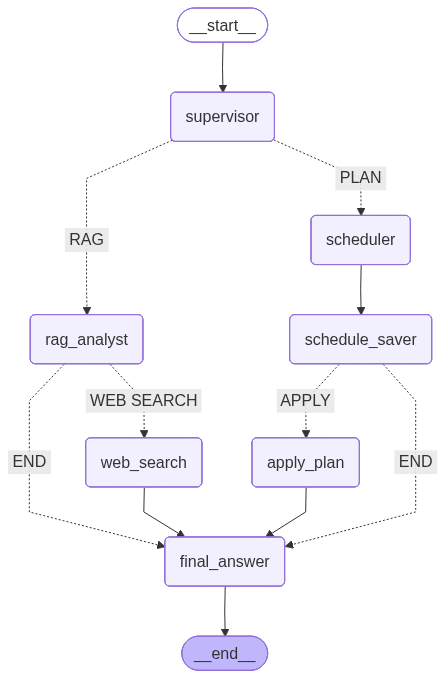

In [237]:
from IPython.display import Image, display

# Generate the graph and display it as a PNG
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
def run_app(user_query: str, process: bool = False):
    if process:
        process_documents(False)
        process_files()
    """
    Executes the LangGraph pipeline, traces node activity, 
    and outputs the final synthesized response.
    """
    print(f"\n{'='*60}\n>>> EXECUTING QUERY: '{user_query}'\n{'='*60}")
    
    initial_state = {
        "user_prompt": user_query,
        "messages": []
    }

    latest_state = {}
    try:
        for output in app.stream(initial_state):
            for node_name, state_update in output.items():
                print(f"[{node_name.upper()} Node Completed]")
                # Dynamically accumulate updated keys 
                for key, value in state_update.items():
                    latest_state[key] = value
        

        print("\n" + "="*60)
        print("FINAL ANSWER:")
        
        # Extract the final answer generated by the final_synthesizer_node
        print(latest_state.get("answer", "No answer found in state."))
        
        # Optional: Print citations if they were populated
        citations = latest_state.get("source_citations", [])

        print("\n" + "="*60)
        if citations:
            print(f"\n[Sources Cited: {citations}]")
            
    except Exception as e:
         print(f"\n[X] Pipeline execution failed: {e}")

In [242]:
queries = [
    "Explain what the core fundamentals of a business are.",
    "Who won the FIFA World Cup in 2026?",
    "Schedule a 1-hour Capstone Project sync with my advisor today at 5 PM.",
    "Block my calendar for a study session on Friday morning."
]

In [245]:
for x in queries:
    run_app(user_query = x)

Starting document extraction pipeline...
Extraction Complete
Enter proper file path to preferred file.
Enter q to quit

  [!] Timeout reached (10s). Automatically defaulting to 'q'.

>>> EXECUTING QUERY: 'Explain what the core fundamentals of a business are.'
[SUPERVISOR Node Completed]
[RAG_ANALYST Node Completed]
[WEB_SEARCH Node Completed]
[FINAL_ANSWER Node Completed]

FINAL ANSWER:
Based on the provided academic materials, the core fundamentals of a business are defined by its purpose, strategic direction, and guiding principles:

*   **Purpose of Business:** The fundamental purpose of a business is to generate profit in a legitimate way on a long-term, sustainable basis.
*   **Vision:** This provides the company with direction by describing its future, overall purpose, and aspirational goals (e.g., the problems it aims to solve or the impact it seeks to make).
*   **Mission Statement:** This defines why an organization exists and what its overall current goal is. Unlike the visio

KeyboardInterrupt: 